# Linear Models for ETF Cross-Asset Momentum

**Docker image**: `ml4t`

With 99 eligible ETFs spanning 9 asset classes, regularization matters for
linear prediction: feature families are correlated (157 pairs with |r| > 0.7),
and the monthly horizon (21-day forward returns) amplifies noise relative to
signal. This notebook trains OLS, Ridge, Lasso, and ElasticNet across a wide
regularization grid to find the shrinkage level that best separates signal
from collinearity-induced noise.

**Learning Objectives**:
- Train regularized linear models on walk-forward folds (10-year train, 1-year val)
- Compare L1, L2, and elastic net regularization on a correlated feature set
- Evaluate how regularization strength affects predictive IC
- Generate backtesting-ready predictions for downstream strategy simulation (Ch16)

**Book Reference**: Chapter 11, Section 11.8 (Case Study Results)

**Prerequisites**: `03_financial_features.py`, `04_model_based_features.py`, [`05_evaluation`](05_evaluation.ipynb)

In [1]:
"""Linear Models — walk-forward cross-validation."""

import time
import warnings
from datetime import UTC, datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge

from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import (
    ConfigError,
    load_configs,
    load_modeling_dataset,
    prepare_cv_folds,
    resolve_linear_params,
)
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
if not PRIMARY_LABEL:
    setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
    PRIMARY_LABEL = setup["labels"]["primary"]

## 1. Load Data and Model Configs

Model configurations are defined in `config/training/{label}.yaml`. Each entry
references a preset in `config/` — a complete specification of
the sklearn class and its constructor parameters. To modify the grid,
edit the label config file: comment out presets or add new ones.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 394,233 rows × 71 features
Label: fwd_ret_21d | Task: regression | Folds: 8


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="linear")

print(f"\n{len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits\n")
for cfg in configs:
    params_str = (
        ", ".join(f"{k}={v}" for k, v in cfg["params"].items()) if cfg["params"] else "defaults"
    )
    print(f"  {cfg['config_name']:25s}  {cfg['model_class']}({params_str})")


28 configs × 8 folds = 224 fits

  ols                        LinearRegression(defaults)
  ridge_a0.001               Ridge(alpha=0.001)
  ridge_a0.01                Ridge(alpha=0.01)
  ridge_a0.1                 Ridge(alpha=0.1)
  ridge_a1.0                 Ridge(alpha=1.0)
  ridge_a10.0                Ridge(alpha=10.0)
  ridge_a100.0               Ridge(alpha=100.0)
  ridge_a1000.0              Ridge(alpha=1000.0)
  ridge_a10000.0             Ridge(alpha=10000.0)
  ridge_a100000.0            Ridge(alpha=100000.0)
  ridge_a1000000.0           Ridge(alpha=1000000.0)
  ridge_a10000000.0          Ridge(alpha=10000000.0)
  lasso_f0.5                 Lasso(alpha_frac=0.5, max_iter=5000)
  lasso_f0.2                 Lasso(alpha_frac=0.2, max_iter=5000)
  lasso_f0.08                Lasso(alpha_frac=0.08, max_iter=5000)
  lasso_f0.03                Lasso(alpha_frac=0.03, max_iter=5000)
  lasso_f0.015               Lasso(alpha_frac=0.015, max_iter=5000)
  lasso_f0.35                Lasso(alph

## 2. Prepare CV Folds

Each fold preprocesses training data (median imputation for missing features,
standard scaling) and applies the same transformation to the validation set.

In [6]:
dataset_pd = dataset.to_pandas()
folds = prepare_cv_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in folds:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=227,101  val=24,190
  Fold 1: train=222,805  val=23,940
  Fold 2: train=217,733  val=23,940
  Fold 3: train=210,654  val=23,942
  Fold 4: train=203,290  val=24,192
  Fold 5: train=192,472  val=24,186
  Fold 6: train=179,598  val=23,664
  Fold 7: train=157,397  val=22,180


## 3. Walk-Forward Cross-Validation

For each configuration, fit the model on each training fold and predict
the validation fold. Cross-sectional IC (Spearman rank correlation per
date, averaged) measures predictive quality.

In [7]:
# sklearn class lookup — maps model_class strings from presets to classes
MODEL_CLASSES = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "LogisticRegression": LogisticRegression,
}

results = []
for cfg in configs:
    cls = MODEL_CLASSES.get(cfg["model_class"])
    if cls is None:
        raise ConfigError(
            f"Unknown model_class '{cfg['model_class']}' in preset '{cfg['config_name']}'.\n"
            f"Available: {list(MODEL_CLASSES.keys())}"
        )

    config_started_at = datetime.now(UTC).isoformat()
    config_t0 = time.perf_counter()

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _early_spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    _status = training_run_status(CASE_STUDY_ID, _early_spec)
    _training_hash = training_hash_from_spec(_early_spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        # Already trained + registered: load the cached IC from the registry
        # and append it so the Results Summary renders on a fully-cached
        # checkout. (A bare `continue` here drops the config from `results`,
        # printing an empty summary table when every config is registered.)
        _pred_hash = _split_rows["prediction_hash"][0]
        _metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=_pred_hash)
        _ic_mean = float(_metrics["ic_mean"][0]) if not _metrics.is_empty() else np.nan
        _ic_std = float(_metrics["ic_std"][0]) if not _metrics.is_empty() else np.nan
        # ic_n_days = number of validation dates that produced a defined daily IC.
        # A config that shrinks to ~constant predictions on some folds yields no
        # cross-sectional IC on those dates, so its n_days is below the full-coverage
        # maximum. §4 uses this to keep partial-coverage configs out of the ranking.
        _ic_n_days = float(_metrics["ic_n_days"][0]) if not _metrics.is_empty() else np.nan
        print(
            f"  {cfg['config_name']:25s}  IC={_ic_mean:+.4f} ± {_ic_std:.4f}  "
            f"(cached, {_status.summary()})"
        )
        results.append(
            {
                "config": cfg,
                "predictions": pd.DataFrame(),
                "ic_mean": _ic_mean,
                "ic_std": _ic_std,
                "ic_n_days": _ic_n_days,
                "fold_ics": [],
                "degenerate": False,
                "cached": True,
                "started_at": None,
                "elapsed_s": 0.0,
            }
        )
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN — missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN — partial state: {_status.summary()}")

    fold_preds = []
    fold_ics = []
    fold_coefs = []

    for fold in folds:
        try:
            model = cls(**resolve_linear_params(cfg, fold["X_train"], fold["y_train"]))
        except TypeError as e:
            raise ConfigError(
                f"Cannot create {cfg['model_class']} from preset '{cfg['config_name']}'.\n"
                f"Check preset params for {cfg['config_name']}: {e}"
            ) from e

        model.fit(fold["X_train"], fold["y_train"])

        # Check for degenerate model (all coefficients zero — regularization too strong)
        if hasattr(model, "coef_") and np.all(model.coef_ == 0):
            degenerate = True
            break

        # Store coefficients (feature weights + intercept)
        if hasattr(model, "coef_"):
            coefs = model.coef_.ravel() if model.coef_.ndim > 1 else model.coef_
            intercept = model.intercept_ if np.isscalar(model.intercept_) else model.intercept_[0]
            for feat, c in zip(feature_names, coefs, strict=False):
                fold_coefs.append(
                    {
                        "config_name": cfg["config_name"],
                        "fold": fold["fold"],
                        "feature": feat,
                        "coefficient": float(c),
                    }
                )
            fold_coefs.append(
                {
                    "config_name": cfg["config_name"],
                    "fold": fold["fold"],
                    "feature": "_intercept_",
                    "coefficient": float(intercept),
                }
            )

        # Classification: use expected value of class probabilities for IC
        if mds.task_type == "classification" and hasattr(model, "predict_proba"):
            proba = model.predict_proba(fold["X_val"])
            preds = proba @ np.array(sorted(mds.class_values), dtype=np.float64)
        else:
            preds = model.predict(fold["X_val"])

        ic_frame = pl.DataFrame(
            {
                "date": fold["dates"],
                "symbol": fold["entities"],
                "y_true": fold["y_val"],
                "y_pred": preds,
            }
        )
        ic = cross_sectional_ic(
            ic_frame,
            ic_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        fold_ics.append(ic)

        # Assemble prediction DataFrame for this fold
        pred_df = fold["meta"][mds.join_cols].copy()
        pred_df["fold"] = fold["fold"]
        pred_df["prediction"] = preds
        pred_df["actual"] = fold["y_val"]
        fold_preds.append(pred_df)
    else:
        degenerate = False

    config_elapsed = time.perf_counter() - config_t0

    if degenerate:
        print(
            f"  {cfg['config_name']:25s}  SKIP — all coefficients zero (regularization too strong)"
        )
        results.append(
            {
                "config": cfg,
                "predictions": pd.DataFrame(),
                "ic_mean": np.nan,
                "ic_std": np.nan,
                # Coverage is only known once metrics are registered and reloaded on
                # the next cached run; inline it stays unknown (NaN).
                "ic_n_days": np.nan,
                "fold_ics": [],
                "degenerate": True,
                "started_at": config_started_at,
                "elapsed_s": config_elapsed,
            }
        )
        continue

    ic_mean = float(np.nanmean(fold_ics))
    ic_std = float(np.nanstd(fold_ics))
    print(f"  {cfg['config_name']:25s}  IC={ic_mean:+.4f} ± {ic_std:.4f}  ({config_elapsed:.1f}s)")

    results.append(
        {
            "config": cfg,
            "predictions": pd.concat(fold_preds, ignore_index=True),
            "ic_mean": ic_mean,
            "ic_std": ic_std,
            # Coverage is populated on the next cached run from the registry.
            "ic_n_days": np.nan,
            "fold_ics": fold_ics,
            "coefficients": fold_coefs,
            "degenerate": False,
            "started_at": config_started_at,
            "elapsed_s": config_elapsed,
        }
    )

  ols                        IC=+0.0269 ± 0.0740  (cached, complete (hash=31ac8f2c4096))
  ridge_a0.001               IC=+0.0269 ± 0.0740  (cached, complete (hash=fc6a2c5dda8d))
  ridge_a0.01                IC=+0.0269 ± 0.0740  (cached, complete (hash=2617a804b1f4))
  ridge_a0.1                 IC=+0.0268 ± 0.0740  (cached, complete (hash=6f3de862b64e))
  ridge_a1.0                 IC=+0.0268 ± 0.0740  (cached, complete (hash=31529f2d0f78))
  ridge_a10.0                IC=+0.0268 ± 0.0740  (cached, complete (hash=6781dd2af9b8))
  ridge_a100.0               IC=+0.0267 ± 0.0733  (cached, complete (hash=697afbbdf17f))
  ridge_a1000.0              IC=+0.0277 ± 0.0706  (cached, complete (hash=7226f3f2d844))
  ridge_a10000.0             IC=+0.0331 ± 0.0678  (cached, complete (hash=ecbb7e087782))
  ridge_a100000.0            IC=+0.0357 ± 0.0548  (cached, complete (hash=42e86ed5e992))
  ridge_a1000000.0           IC=+0.0420 ± 0.0395  (cached, complete (hash=1957228a8dcb))
  ridge_a10000000.0  

## 4. Results Summary

Rank configs by mean IC. Group by model family (OLS, Ridge, Lasso, ElasticNet)
and report the best regularization strength per family.

In [8]:
# Sort by IC descending
results.sort(key=lambda r: r["ic_mean"] if np.isfinite(r["ic_mean"]) else -np.inf, reverse=True)

active = [r for r in results if not r.get("degenerate")]
degenerate = [r for r in results if r.get("degenerate")]

# Full-coverage guard for ranking/winner selection.
# A config that shrinks to ~constant predictions on some folds (a high-L1 Lasso
# or ElasticNet whose coefficients collapse to one or two features) produces no
# cross-sectional IC on those validation dates, so its IC is computed on only a
# subset of days (ic_n_days below the full-coverage maximum). A partial-coverage
# IC is not comparable to a full-coverage one and must not lead the ranking - the
# same guard 13_model_analysis applies to its per-family leaders. We keep the
# all-zero `degenerate` exclusion above for `active` and registration, and layer
# this coverage split on top for the ranking and the reported winner only.
_finite_days = [r["ic_n_days"] for r in active if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    # Cached / reproduce path: coverage is known from the registry.
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in active
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in active if r not in full_cov]
else:
    # Pure retrain path: coverage is unknown inline, so the guard cannot apply.
    # Fall back to the full active set (coverage is populated on the next cached run).
    _full_days = None
    full_cov = active
    partial_cov = []

print(f"{'Config':25s}  {'IC Mean':>9s}  {'IC Std':>8s}  {'N Days':>7s}")
print("-" * 56)
for r in full_cov:
    _nd = r.get("ic_n_days", np.nan)
    _nd_str = f"{int(_nd):>7d}" if np.isfinite(_nd) else f"{'n/a':>7s}"
    print(f"  {r['config']['config_name']:25s}  {r['ic_mean']:+.4f}  {r['ic_std']:.4f}  {_nd_str}")

if partial_cov:
    print("\nPartial coverage (degenerate on some folds — excluded from ranking):")
    for r in partial_cov:
        _nd = r.get("ic_n_days", np.nan)
        _nd_str = f"{int(_nd)}" if np.isfinite(_nd) else "n/a"
        print(
            f"  {r['config']['config_name']:25s}  IC={r['ic_mean']:+.4f}  "
            f"n_days={_nd_str} (of {int(_full_days)})"
        )

if degenerate:
    print(f"\nSkipped ({len(degenerate)} degenerate — all coefficients zero):")
    for r in degenerate:
        print(f"  {r['config']['config_name']}")

best = full_cov[0] if full_cov else None  # active is already sorted desc by ic_mean
if best:
    print(f"\nBest (full coverage): {best['config']['config_name']} (IC={best['ic_mean']:+.4f})")

Config                       IC Mean    IC Std   N Days
--------------------------------------------------------
  ridge_a1000000.0           +0.0420  0.0395     2016
  ridge_a10000000.0          +0.0374  0.0408     2016
  ridge_a100000.0            +0.0357  0.0548     2016
  ridge_a10000.0             +0.0331  0.0678     2016
  enet_f0.7                  +0.0287  0.0553     2016
  lasso_f0.7                 +0.0286  0.0553     2016
  enet_f0.08                 +0.0280  0.0654     2016
  lasso_f0.08                +0.0278  0.0653     2016
  ridge_a1000.0              +0.0277  0.0706     2016
  ridge_a0.001               +0.0269  0.0740     2016
  ols                        +0.0269  0.0740     2016
  ridge_a0.01                +0.0269  0.0740     2016
  ridge_a0.1                 +0.0268  0.0740     2016
  ridge_a1.0                 +0.0268  0.0740     2016
  ridge_a10.0                +0.0268  0.0740     2016
  ridge_a100.0               +0.0267  0.0733     2016
  lasso_f0.2           

### Full-coverage IC ranking

The bar chart ranks the full-coverage linear configs by validation IC. Ridge's
strong-shrinkage settings lead; the partial-coverage L1 configs are excluded
from the ranking (their IC is measured on fewer validation dates), so the chart
reflects the winner the guard above selects.

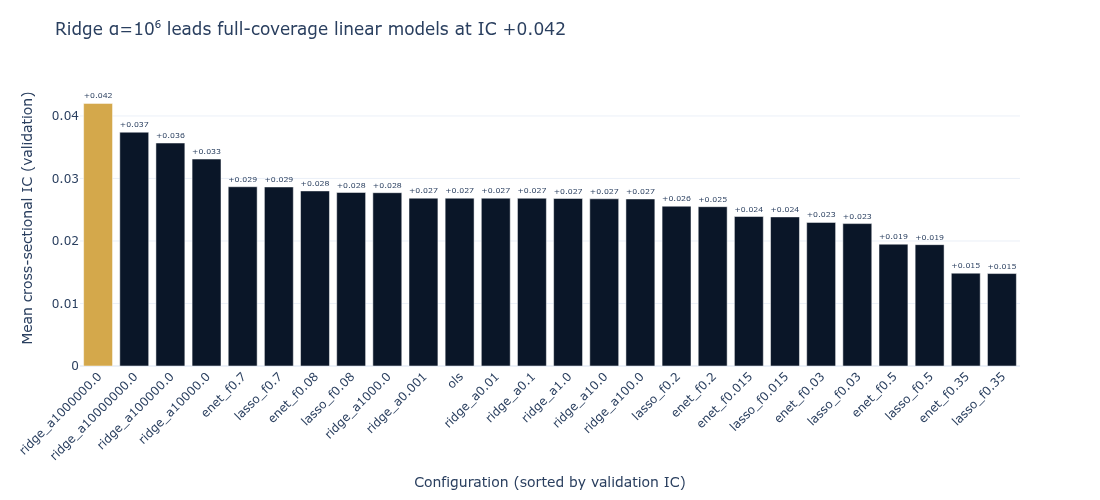

In [9]:
_SUP = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")


def _pretty_config(name):
    """Human-readable label for a config; renders ridge alpha as a power of ten."""
    if name.startswith("ridge_a"):
        alpha = float(name.split("_a")[1])
        exp = int(round(np.log10(alpha)))
        return f"Ridge α=10{str(exp).translate(_SUP)}"
    return name


# Figure 1 — full-coverage IC ranking (leader highlighted; partials excluded).
_names = [r["config"]["config_name"] for r in full_cov]
_ics = [r["ic_mean"] for r in full_cov]
_leader = best["config"]["config_name"] if best else None
_bar_colors = [COLORS["amber"] if n == _leader else COLORS["blue"] for n in _names]
fig_ic = go.Figure(
    go.Bar(
        x=_names,
        y=_ics,
        marker_color=_bar_colors,
        text=[f"{v:+.3f}" for v in _ics],
        textposition="outside",
        cliponaxis=False,
    )
)
_lead_ic = best["ic_mean"] if best else float("nan")
fig_ic.update_layout(
    title=f"{_pretty_config(_leader)} leads full-coverage linear models at IC {_lead_ic:+.3f}",
    template="plotly_white",
    height=500,
    width=1100,
    showlegend=False,
    margin=dict(t=70),
)
fig_ic.update_xaxes(title_text="Configuration (sorted by validation IC)", tickangle=-45)
fig_ic.update_yaxes(title_text="Mean cross-sectional IC (validation)")
fig_ic.show()

### Ridge regularization sweep

Tracing IC across the Ridge penalty isolates the effect of shrinkage on a set of
correlated features. The curve is single-peaked: IC is flat at weak penalties,
rises as shrinkage collapses correlated feature groups, peaks, then falls once
over-shrinkage erodes the signal.

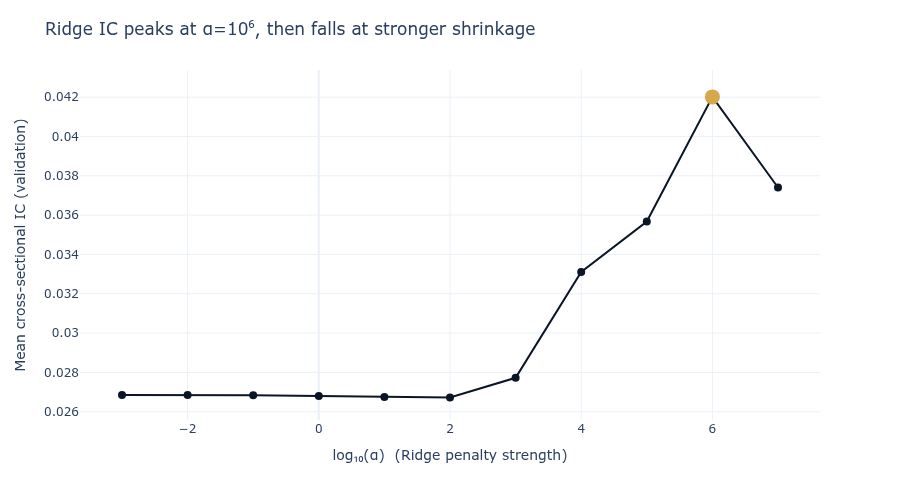

In [10]:
# Figure 2 — Ridge alpha sweep (IC vs log10 alpha), peak highlighted.
_ridge = sorted(
    (float(r["config"]["config_name"].split("_a")[1]), r["ic_mean"])
    for r in active
    if r["config"]["config_name"].startswith("ridge_a")
)
_logalpha = [np.log10(a) for a, _ in _ridge]
_ridge_ic = [ic for _, ic in _ridge]
_peak_i = int(np.argmax(_ridge_ic)) if _ridge_ic else 0
fig_alpha = go.Figure(
    go.Scatter(
        x=_logalpha,
        y=_ridge_ic,
        mode="lines+markers",
        line=dict(color=COLORS["blue"], width=2),
        marker=dict(size=8, color=COLORS["blue"]),
        name="Ridge IC",
    )
)
if _ridge_ic:
    fig_alpha.add_trace(
        go.Scatter(
            x=[_logalpha[_peak_i]],
            y=[_ridge_ic[_peak_i]],
            mode="markers",
            marker=dict(size=15, color=COLORS["amber"]),
            name="peak",
            showlegend=False,
        )
    )
_peak_exp = int(round(_logalpha[_peak_i])) if _ridge_ic else 0
fig_alpha.update_layout(
    title=f"Ridge IC peaks at α=10{str(_peak_exp).translate(_SUP)}, then falls at stronger shrinkage",
    template="plotly_white",
    height=500,
    width=900,
    showlegend=False,
    margin=dict(t=70),
)
fig_alpha.update_xaxes(title_text="log₁₀(α)  (Ridge penalty strength)")
fig_alpha.update_yaxes(title_text="Mean cross-sectional IC (validation)")
fig_alpha.show()

**Interpretation**: Ridge at $\alpha = 10^6$ is the full-coverage linear leader,
with validation IC $\approx +0.042$ - above unregularized OLS ($\approx +0.027$).
The Ridge alpha sweep is single-peaked: IC is flat near $+0.027$ for weak
penalties, rises with shrinkage to peak at $\alpha = 10^6$, then falls at
$10^7$ as over-shrinkage erodes the signal. This is the signature of a
correlated feature set: moderate shrinkage collapses feature groups, while
strong shrinkage effectively performs a soft principal-component projection.

The two most aggressive L1 settings (`enet_f0.85`, `lasso_f0.85`) show a higher
raw IC ($\approx +0.054$), but only because they collapse to roughly two
features on several folds and therefore produce no cross-sectional IC on about
500 of the 2016 validation dates. That is a partial-coverage artifact, not a
real edge, so the full-coverage guard excludes them from the ranking. Among the
full-coverage configs, hard L1 feature selection does *not* match dense
shrinkage here (the best full-coverage L1, `enet_f0.7`, reaches only
$\approx +0.029$): Ridge's dense shrinkage of the correlated feature set has a
real, not marginal, edge.

## 5. Register Results

Each config is registered in the unified registry with its predictions,
IC metrics, and full provenance (training hash = SHA256 of config + label
+ features + folds). Identical configs produce the same hash — re-running
updates rather than duplicates.

In [11]:
for r in active:
    if r.get("cached"):
        continue  # already registered on a prior run; predictions not reloaded
    cfg = r["config"]
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    t_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="06_linear",
        started_at=r.get("started_at"),
        elapsed_s=r.get("elapsed_s"),
    )

    # Save coefficients to registry training dir
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    coefs = r.get("coefficients", [])
    if coefs:
        pd.DataFrame(coefs).to_parquet(train_dir / "coefficients.parquet", index=False)

    metrics = {"ic_mean": r["ic_mean"], "ic_std": r["ic_std"]}
    register_prediction_set(
        CASE_STUDY_ID,
        t_hash,
        split=PREDICTION_SPLIT,
        predictions=r["predictions"],
        metrics=metrics,
        task_type=mds.task_type,
        class_values=mds.class_values or None,
    )
    print(f"  registered {cfg['config_name']:25s}  IC={r['ic_mean']:+.4f}")

## 6. Key Takeaways

Ridge at $\alpha = 10^6$ gives the best full-coverage linear IC
($\approx +0.042$), meaningfully above unregularized OLS ($\approx +0.027$):
with 71 correlated features, dense shrinkage extracts signal that would
otherwise be buried in multicollinearity noise. The alpha sweep is
single-peaked - IC is flat at weak penalties, peaks at $10^6$, then declines
at $10^7$ as over-shrinkage erodes the signal.

The L1 grid is calibrated to each fold's degeneracy threshold ($\alpha_{\max}$,
the smallest penalty that zeros every coefficient), but the most aggressive
settings still collapse to about two features on some folds. There they produce
constant predictions with no cross-sectional IC, so their apparently higher raw
IC ($\approx +0.054$) is measured on a subset of dates - a partial-coverage
artifact the full-coverage guard excludes from the ranking. Among full-coverage
configs, hard feature selection does not match dense shrinkage (best
full-coverage L1 $\approx +0.029$), so Ridge's edge over sparse L1 is real, not
marginal.

**Next**: [`07_gbm`](07_gbm.ipynb) tests gradient boosting with tree depth × loss
configurations to evaluate whether non-linear feature interactions — particularly
the HMM stress regime interacting with momentum — can improve on the linear baseline.